In [ ]:
import numpy as np
from collections import Counter

#Defining the Euclidean Distance Function

In [ ]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

# KNN Prediction Function

In [ ]:
def knn_predict(training_data, training_labels, test_point, k):
    distances = []

    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
        print(distances)
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]


In [ ]:
training_data = [[1, 2], [2, 3], [3, 4],[6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3

In [ ]:
prediction = knn_predict(training_data, training_labels, test_point, k)
print(prediction)

[(np.float64(4.242640687119285), 'A')]
[(np.float64(4.242640687119285), 'A'), (np.float64(2.8284271247461903), 'A')]
[(np.float64(4.242640687119285), 'A'), (np.float64(2.8284271247461903), 'A'), (np.float64(1.4142135623730951), 'A')]
[(np.float64(4.242640687119285), 'A'), (np.float64(2.8284271247461903), 'A'), (np.float64(1.4142135623730951), 'A'), (np.float64(2.8284271247461903), 'B')]
[(np.float64(4.242640687119285), 'A'), (np.float64(2.8284271247461903), 'A'), (np.float64(1.4142135623730951), 'A'), (np.float64(2.8284271247461903), 'B'), (np.float64(4.242640687119285), 'B')]
A


#KNN dataset practicing

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Pokemon.csv")
df

,SN,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Attack,Sp. Defense,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SN           800 non-null    int64 
 1   Name         800 non-null    object
 2   Type 1       800 non-null    object
 3   Type 2       414 non-null    object
 4   HP           800 non-null    int64 
 5   Attack       800 non-null    int64 
 6   Defense      800 non-null    int64 
 7   Sp. Attack   800 non-null    int64 
 8   Sp. Defense  800 non-null    int64 
 9   Speed        800 non-null    int64 
 10  Generation   800 non-null    int64 
 11  Legendary    800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [ ]:
df.describe()

,SN,HP,Attack,Defense,Sp. Attack,Sp. Defense,Speed,Generation
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
SN,0
Name,0
Type 1,0
Type 2,386
HP,0
Attack,0
Defense,0
Sp. Attack,0
Sp. Defense,0
Speed,0


In [ ]:
q1=df["SN"].quantile(0.25)
q3=df["SN"].quantile(0.75)
IQR=q3 - q1
up=q3+1.5*IQR
lo=q1-1.5*IQR
df = df[(df["SN"] > lo) & (df["SN"] < up)]
display(up,lo)

np.float64(1071.0)

np.float64(-347.0)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Legendary"] =le.fit_transform(df["Legendary"])
df

,SN,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Attack,Sp. Defense,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,0
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,0
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,0
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,0
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,50,100,150,100,150,50,6,1
796,719,DiancieMega Diancie,Rock,Fairy,50,160,110,160,110,110,6,1
797,720,HoopaHoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,1
798,720,HoopaHoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,1


In [ ]:
feature=df.drop(columns=['Type 1','Name','Type 2'], axis=1)
target=df['Type 1']

In [ ]:
feature


,SN,HP,Attack,Defense,Sp. Attack,Sp. Defense,Speed,Generation,Legendary
0,1,45,49,49,65,65,45,1,0
1,2,60,62,63,80,80,60,1,0
2,3,80,82,83,100,100,80,1,0
3,3,80,100,123,122,120,80,1,0
4,4,39,52,43,60,50,65,1,0
...,...,...,...,...,...,...,...,...,...
795,719,50,100,150,100,150,50,6,1
796,719,50,160,110,160,110,110,6,1
797,720,80,110,60,150,130,70,6,1
798,720,80,160,60,170,130,80,6,1


In [ ]:
from sklearn.model_selection import train_test_split

feature_train, feature_test, target_train, target_test=train_test_split(feature,target,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
feature_train=sc.fit_transform(feature_train)
feature_train

array([[-0.55832801,  1.18102488, -0.12394934, ...,  0.57047837,
        -0.7895929 ,  3.26134384],
       [ 0.94330247,  1.37420995,  1.88708514, ...,  0.91265846,
         1.02817493, -0.30662207],
       [-0.27737779, -0.75082587,  0.80422042, ..., -0.62715195,
        -0.18367029, -0.30662207],
       ...,
       [-0.53410817,  1.41284697,  1.57769522, ...,  0.74156842,
        -0.7895929 ,  3.26134384],
       [ 0.14404754, -0.98264796, -0.6499122 , ..., -0.25075385,
         0.42225232, -0.30662207],
       [-1.28976738, -0.36445572, -0.43333926, ...,  2.11028879,
        -1.39551551, -0.30662207]])

In [ ]:
feature_test=sc.fit_transform(feature_test)
feature_test

array([[ 1.21936739,  0.9766294 ,  0.79097286, ...,  1.0573681 ,
         0.93933644, -0.25819889],
       [ 1.08438959,  0.26824754, -0.12103044, ..., -0.99200031,
         0.93933644, -0.25819889],
       [-1.46622551, -0.56514288, -0.27303099, ..., -0.28532155,
        -1.41821384, -0.25819889],
       ...,
       [ 1.41019808,  0.26824754,  0.03097011, ...,  1.19870385,
         1.528724  , -0.25819889],
       [ 0.41415496,  0.05989994, -0.27303099, ..., -0.28532155,
         0.34994887, -0.25819889],
       [ 1.09835281, -0.35679527, -0.72903263, ...,  0.42135721,
         0.93933644, -0.25819889]])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier()
knn_model.fit(feature_train,target_train)

KNeighborsClassifier()

In [ ]:
prediction=knn_model.predict(feature_test)
prediction

array(['Water', 'Water', 'Fire', 'Electric', 'Normal', 'Bug', 'Normal',
       'Bug', 'Dark', 'Ghost', 'Normal', 'Bug', 'Grass', 'Water', 'Bug',
       'Water', 'Psychic', 'Water', 'Water', 'Electric', 'Bug', 'Steel',
       'Grass', 'Electric', 'Fire', 'Normal', 'Normal', 'Bug', 'Electric',
       'Fire', 'Electric', 'Bug', 'Normal', 'Normal', 'Poison', 'Fire',
       'Water', 'Normal', 'Dragon', 'Fighting', 'Bug', 'Poison', 'Water',
       'Steel', 'Electric', 'Fire', 'Dragon', 'Normal', 'Bug', 'Electric',
       'Water', 'Electric', 'Ice', 'Fire', 'Fire', 'Grass', 'Bug',
       'Steel', 'Normal', 'Water', 'Fire', 'Bug', 'Fighting', 'Fire',
       'Bug', 'Dragon', 'Grass', 'Rock', 'Water', 'Grass', 'Dark',
       'Electric', 'Fire', 'Rock', 'Fire', 'Normal', 'Water', 'Steel',
       'Ground', 'Electric', 'Psychic', 'Bug', 'Poison', 'Fire', 'Normal',
       'Ghost', 'Rock', 'Dark', 'Normal', 'Water', 'Fire', 'Water', 'Bug',
       'Water', 'Dark', 'Water', 'Flying', 'Grass', 'Fire', '

In [ ]:
pred=pd.DataFrame({"Actual data":target_test,"Predicted data":prediction})
pred

,Actual data,Predicted data
696,Dark,Water
667,Psychic,Water
63,Fire,Fire
533,Electric,Electric
66,Water,Normal
...,...,...
589,Ground,Normal
798,Psychic,Dragon
744,Normal,Normal
513,Electric,Electric


In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [ ]:
con=confusion_matrix(target_test,prediction)
con

array([[6, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2],
       [0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 5, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 3, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 1, 0],
       [3, 1, 0, 0, 1, 1, 3, 0, 1, 2, 0, 0, 1, 1, 0, 1, 0, 3],
       [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 2, 1, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
       [3, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 2],
       [0, 1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 1, 0, 1],
       [1, 1, 1, 3, 1, 0, 2, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 2],
       [1, 1, 1, 0, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0,

<Axes: >

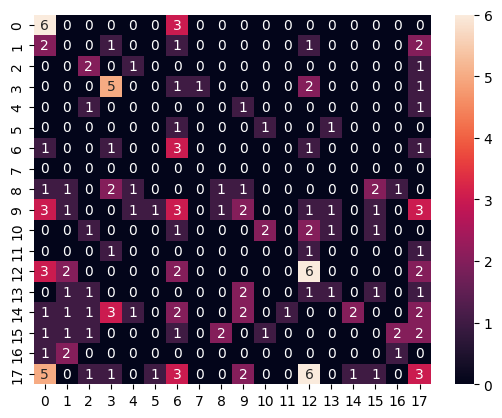

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(con,annot=True)

In [ ]:
accuracy=accuracy_score(target_test,prediction)
print(f"Accuracy is {accuracy*100}%")

Accuracy is 21.25%


In [ ]:
report=classification_report(target_test,prediction)
print(report)

              precision    recall  f1-score   support

         Bug       0.25      0.67      0.36         9
        Dark       0.00      0.00      0.00         7
      Dragon       0.25      0.50      0.33         4
    Electric       0.36      0.50      0.42        10
       Fairy       0.00      0.00      0.00         3
    Fighting       0.00      0.00      0.00         3
        Fire       0.14      0.43      0.21         7
      Flying       0.00      0.00      0.00         0
       Ghost       0.25      0.10      0.14        10
       Grass       0.20      0.11      0.14        18
      Ground       0.50      0.25      0.33         8
         Ice       0.00      0.00      0.00         3
      Normal       0.29      0.40      0.33        15
      Poison       0.25      0.12      0.17         8
     Psychic       0.67      0.12      0.21        16
        Rock       0.00      0.00      0.00        11
       Steel       0.25      0.25      0.25         4
       Water       0.15    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
report=classification_report(target_test,prediction)
print(f"Classification Report\n {report}")

Classification Report
               precision    recall  f1-score   support

         Bug       0.25      0.67      0.36         9
        Dark       0.00      0.00      0.00         7
      Dragon       0.25      0.50      0.33         4
    Electric       0.36      0.50      0.42        10
       Fairy       0.00      0.00      0.00         3
    Fighting       0.00      0.00      0.00         3
        Fire       0.14      0.43      0.21         7
      Flying       0.00      0.00      0.00         0
       Ghost       0.25      0.10      0.14        10
       Grass       0.20      0.11      0.14        18
      Ground       0.50      0.25      0.33         8
         Ice       0.00      0.00      0.00         3
      Normal       0.29      0.40      0.33        15
      Poison       0.25      0.12      0.17         8
     Psychic       0.67      0.12      0.21        16
        Rock       0.00      0.00      0.00        11
       Steel       0.25      0.25      0.25         4
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
